# Purpose

Design NPS resin for new [Elegoo Mars 4 Ultra](https://us.elegoo.com/products/elegoo-mars-4-ultra-msla-resin-3d-printer-with-9k-mono-lcd#specification) LCD 3D printer, which has 18 &mu;m pixel size and 405 nm LED source. Use measured LED spectrum, `Elegoo_405nm_Mars4_Ultra_2024-05-16`.

# Imports

In [1]:
from pathlib import Path
import typing

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import matplotlib
#%matplotlib widget
%matplotlib inline

from scipy.optimize import curve_fit
import scipy.integrate as integrate

import spectra.data as data
from spectra.resin import ResinConstituentAbsorber, ResinConstituentMonomer, Resin
from spectra.sourcespectrum import SourceSpectrum
from spectra.utilities import ArrayParams
from spectra.irradiance import Irradiance
from spectra.normalizeddose import NormalizedDose

In [2]:
import sys
!{sys.executable} --version

Python 3.12.2


# Available spectrum data

In [3]:
data.sources

{'365nm_visitech_with_50mm_asahi_filter_2018-11-22': <spectra.sourcespectrum.SourceSpectrum at 0x12fac5880>,
 'Asiga_405nm_100um_fiber-2016-12-14': <spectra.sourcespectrum.SourceSpectrum at 0x12fac5940>,
 'Elegoo_405nm_Mars4_Ultra_2024-05-16': <spectra.sourcespectrum.SourceSpectrum at 0x12fac59d0>,
 'HR1_385nm_100um_fiber-2016-12-14': <spectra.sourcespectrum.SourceSpectrum at 0x12fac5a30>,
 'HR2_385nm_2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x10fe5de80>,
 'HR3.2_365nm_370nm_short_pass_filter-2019-12-31': <spectra.sourcespectrum.SourceSpectrum at 0x12fac5910>,
 'HR3.2_365nm_no_filter-2019-12-31': <spectra.sourcespectrum.SourceSpectrum at 0x12fac5b20>,
 'HR3.3_365nm_370nm_short_pass_filter-2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x12fac5b80>,
 'HR3.3_365nm_no_filter-2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x12fac5be0>,
 'HR3.3_365nm_through_tray_370nm_short_pass_filter-2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x12fac5c40>,
 'HR3.

In [4]:
data.absorbers

{'avobenzone_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x12fac43b0>,
 'avobenzone_in_PEGDA_2020-01-20': <spectra.absorberspectrum.AbsorberSpectrum at 0x128747f80>,
 'benetex_obplus_in PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x10feeae10>,
 'bls99-2_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x12fac4590>,
 'ideal_uniform_absorber': <spectra.absorberspectrum.AbsorberSpectrum at 0x12fac4560>,
 'martius_yellow_in PEGDA_2020-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x12fac4770>,
 'nps_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x10ff069c0>,
 'octocrylene_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x12fac4860>,
 'phenazine_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x12fac4a10>,
 'salicylaldehyde_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x12fac4b00>,
 'sudanI_in_PEGDA_2017-04-13': <spectra.absorberspectru

In [5]:
data.monomers

{'HDDA': Monomer(/Users/nordin/Documents/Projects/3D_printer_spectra_repos/3dprinter_spectra_and_tools/spectra/data/monomers/hdda.json),
 'Ideal': Monomer(/Users/nordin/Documents/Projects/3D_printer_spectra_repos/3dprinter_spectra_and_tools/spectra/data/monomers/ideal.json),
 'PEGDA': Monomer(/Users/nordin/Documents/Projects/3D_printer_spectra_repos/3dprinter_spectra_and_tools/spectra/data/monomers/pegda.json),
 'TET': Monomer(/Users/nordin/Documents/Projects/3D_printer_spectra_repos/3dprinter_spectra_and_tools/spectra/data/monomers/tet.json)}

# Elegoo 405 nm LED spectrum

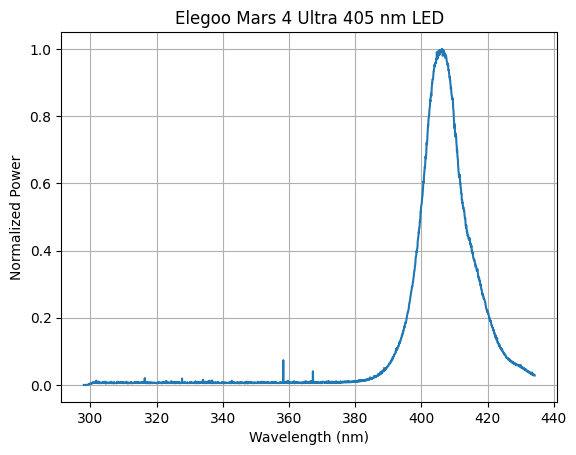

In [7]:
source = data.sources['Elegoo_405nm_Mars4_Ultra_2024-05-16']

fig, ax = plt.subplots()
ax.plot(source.wavelength, source.power)
ax.set_ylabel("Normalized Power")
ax.set_xlabel("Wavelength (nm)")
ax.set_title("Elegoo Mars 4 Ultra 405 nm LED")
ax.grid()

## Compare to other 405 nm LED spectra

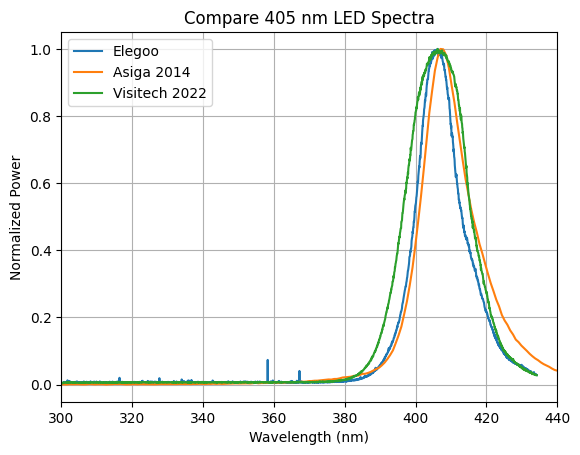

In [11]:
source_asiga = data.sources['Asiga_405nm_100um_fiber-2016-12-14']
source_visitech = data.sources['MR1_405nm_Visitech_unfiltered_2022-08-12']

fig, ax = plt.subplots()
ax.plot(source.wavelength, source.power, label="Elegoo")
ax.plot(source_asiga.wavelength, source_asiga.power, label="Asiga 2014")
ax.plot(source_visitech.wavelength, source_visitech.power, label="Visitech 2022")
ax.set_xlim(300, 440)
ax.set_ylabel("Normalized Power")
ax.set_xlabel("Wavelength (nm)")
ax.set_title("Compare 405 nm LED Spectra")
ax.legend()
ax.grid()

# Initialize parameters

## Resins

In [38]:
# Create resin
pegda = ResinConstituentMonomer(data.monomers['PEGDA'], 100)
nps_3p0 = ResinConstituentAbsorber(
    data.absorbers['nps_in_PEGDA_2017-04-13'],
    3.0
)
nps_2p7 = ResinConstituentAbsorber(
    data.absorbers['nps_in_PEGDA_2017-04-13'],
    2.7
)
nps_2p0 = ResinConstituentAbsorber(
    data.absorbers['nps_in_PEGDA_2017-04-13'],
    2.0
)
nps_1p0 = ResinConstituentAbsorber(
    data.absorbers['nps_in_PEGDA_2017-04-13'],
    1.0
)
nps_0p5 = ResinConstituentAbsorber(
    data.absorbers['nps_in_PEGDA_2017-04-13'],
    0.5
)
irgacure819 = ResinConstituentAbsorber(
    data.photoinitiators['irgacure819_in_PEGDA_2017-04-13'],
    1.0
)
resin_nps3p0 = Resin(monomers=pegda, absorbers=nps_3p0, photoinitiators=irgacure819)
resin_nps2p7 = Resin(monomers=pegda, absorbers=nps_2p7, photoinitiators=irgacure819)
resin_nps2p0 = Resin(monomers=pegda, absorbers=nps_2p0, photoinitiators=irgacure819)
resin_nps1p0 = Resin(monomers=pegda, absorbers=nps_1p0, photoinitiators=irgacure819)
resin_nps0p5 = Resin(monomers=pegda, absorbers=nps_0p5, photoinitiators=irgacure819)
print(f"{resin_nps3p0.name=}")
print(f"{resin_nps2p7.name=}")
print(f"{resin_nps2p0.name=}")
print(f"{resin_nps1p0.name=}")
print(f"{resin_nps0p5.name=}")

resin_nps3p0.name='PEG-100__NPS-3__Irg-1'
resin_nps2p7.name='PEG-100__NPS-2.7__Irg-1'
resin_nps2p0.name='PEG-100__NPS-2__Irg-1'
resin_nps1p0.name='PEG-100__NPS-1__Irg-1'
resin_nps0p5.name='PEG-100__NPS-0.5__Irg-1'


## Wavelength sampling array parameters

In [13]:
wavelength_array_parameters = ArrayParams(300, 440, 401)

# Calculations

In [39]:
irradiance_nps3p0 = Irradiance(source=source, resin=resin_nps3p0, wavelength_array_params=wavelength_array_parameters)
irradiance_nps2p7 = Irradiance(source=source, resin=resin_nps2p7, wavelength_array_params=wavelength_array_parameters)
irradiance_nps2p0 = Irradiance(source=source, resin=resin_nps2p0, wavelength_array_params=wavelength_array_parameters)
irradiance_nps1p0 = Irradiance(source=source, resin=resin_nps1p0, wavelength_array_params=wavelength_array_parameters)
irradiance_nps0p5 = Irradiance(source=source, resin=resin_nps0p5, wavelength_array_params=wavelength_array_parameters)

In [34]:
z_array_params = ArrayParams(0, 100, 201)

PEG-100__NPS-3__Irg-1


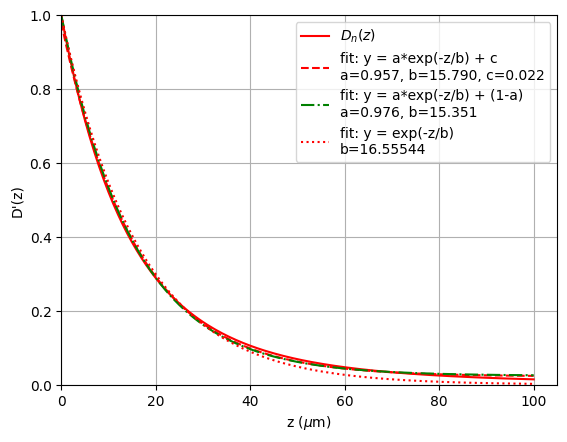

In [35]:
# Normalized dose
norm_dose_nps3p0 = NormalizedDose(irradiance=irradiance_nps3p0, z_array_params=z_array_params)
print(norm_dose_nps3p0.irradiance.resin.name)
norm_dose_nps3p0.plot();

PEG-100__NPS-2.7__Irg-1


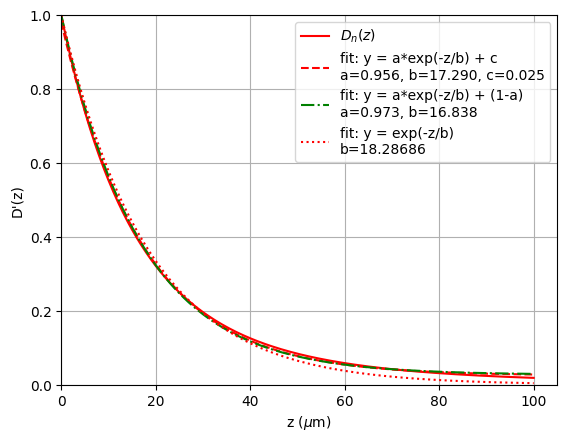

In [40]:
# Normalized dose
norm_dose_nps2p7 = NormalizedDose(irradiance=irradiance_nps2p7, z_array_params=z_array_params)
print(norm_dose_nps2p7.irradiance.resin.name)
norm_dose_nps2p7.plot();

In [46]:
for i in range(45):
    print(f" {i:2d} {norm_dose_nps2p7.z_um[i]:4.1f} {norm_dose_nps2p7.normalized_dose[i]:.3f}")

  0  0.0 1.000
  1  0.5 0.970
  2  1.0 0.940
  3  1.5 0.912
  4  2.0 0.885
  5  2.5 0.858
  6  3.0 0.833
  7  3.5 0.808
  8  4.0 0.784
  9  4.5 0.761
 10  5.0 0.739
 11  5.5 0.717
 12  6.0 0.696
 13  6.5 0.676
 14  7.0 0.657
 15  7.5 0.638
 16  8.0 0.620
 17  8.5 0.602
 18  9.0 0.585
 19  9.5 0.569
 20 10.0 0.553
 21 10.5 0.537
 22 11.0 0.523
 23 11.5 0.508
 24 12.0 0.494
 25 12.5 0.481
 26 13.0 0.467
 27 13.5 0.455
 28 14.0 0.442
 29 14.5 0.431
 30 15.0 0.419
 31 15.5 0.408
 32 16.0 0.397
 33 16.5 0.387
 34 17.0 0.376
 35 17.5 0.366
 36 18.0 0.357
 37 18.5 0.348
 38 19.0 0.339
 39 19.5 0.330
 40 20.0 0.322
 41 20.5 0.313
 42 21.0 0.305
 43 21.5 0.298
 44 22.0 0.290


PEG-100__NPS-2__Irg-1


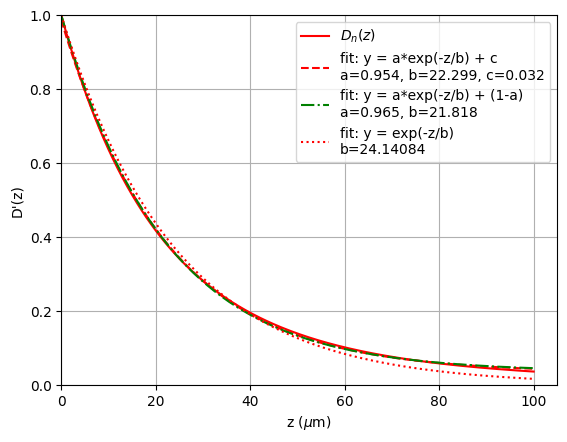

In [36]:
# Normalized dose
norm_dose_nps2p0 = NormalizedDose(irradiance=irradiance_nps2p0, z_array_params=z_array_params)
print(norm_dose_nps2p0.irradiance.resin.name)
norm_dose_nps2p0.plot();

PEG-100__NPS-1__Irg-1


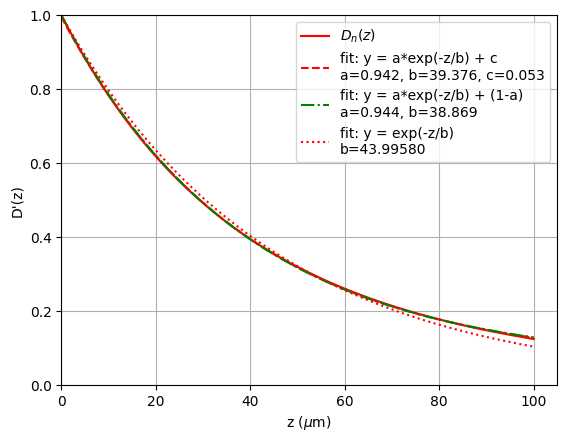

In [16]:
# Normalized dose
norm_dose_nps1p0 = NormalizedDose(irradiance=irradiance_nps1p0, z_array_params=z_array_params)
print(norm_dose_nps1p0.irradiance.resin.name)
norm_dose_nps1p0.plot();

PEG-100__NPS-0.5__Irg-1


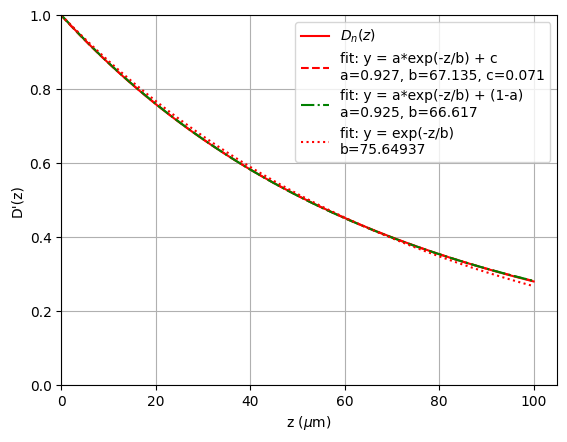

In [17]:
# Normalized dose
norm_dose_nps0p5 = NormalizedDose(irradiance=irradiance_nps0p5, z_array_params=z_array_params)
print(norm_dose_nps0p5.irradiance.resin.name)
norm_dose_nps0p5.plot();

# Optical penetration depth vs NPS concentration

In [49]:
pegda = ResinConstituentMonomer(data.monomers['PEGDA'], 100)
irgacure819 = ResinConstituentAbsorber(
    data.photoinitiators['irgacure819_in_PEGDA_2017-04-13'],
    1.0
)

nps_conc_values = np.linspace(0.5, 2.0, num=16)
optical_penetration_depth = []

for nps_conc in nps_conc_values:
    absorber = ResinConstituentAbsorber(
        data.absorbers['nps_in_PEGDA_2017-04-13'],
        nps_conc
    )
    resin = Resin(monomers=pegda, absorbers=absorber, photoinitiators=irgacure819)
    irradiance = Irradiance(source=source, resin=resin, wavelength_array_params=wavelength_array_parameters)
    norm_dose = NormalizedDose(irradiance=irradiance, z_array_params=z_array_params)
    optical_penetration_depth.append(norm_dose.a_b_model_params['b'])
    

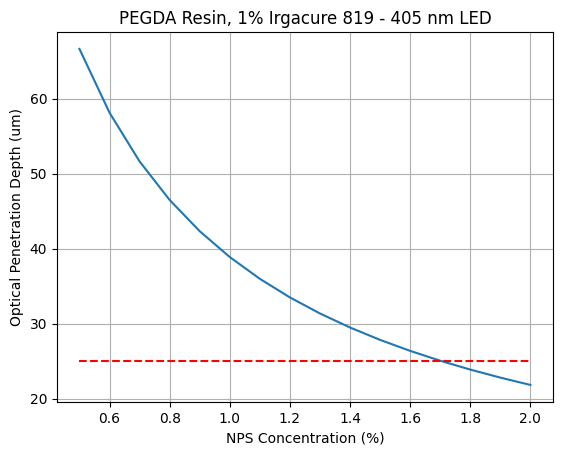

In [50]:
fig, ax = plt.subplots()
ax.plot(nps_conc_values, optical_penetration_depth)
ax.set_xlabel("NPS Concentration (%)")
ax.set_ylabel("Optical Penetration Depth (um)")
ax.set_title("PEGDA Resin, 1% Irgacure 819 - 405 nm LED")
ax.hlines(25, 0.5, 2.0, color="r", ls="--")
ax.grid()
plt.savefig("h_a_vs_NPS_concentration.png")

In [51]:
print("NPS conc. (%) | Optical penetration depth (um)")
print("----------------------------------------------")
for conc, h_a in zip(nps_conc_values, optical_penetration_depth):
    print(f"      {conc:0.2f}    |      {h_a:.2f}")

NPS conc. (%) | Optical penetration depth (um)
----------------------------------------------
      0.50    |      66.62
      0.60    |      58.12
      0.70    |      51.62
      0.80    |      46.48
      0.90    |      42.32
      1.00    |      38.87
      1.10    |      35.97
      1.20    |      33.49
      1.30    |      31.35
      1.40    |      29.48
      1.50    |      27.83
      1.60    |      26.36
      1.70    |      25.05
      1.80    |      23.86
      1.90    |      22.79
      2.00    |      21.82


# NPS 1.7%

PEG-100__NPS-1.7__Irg-1


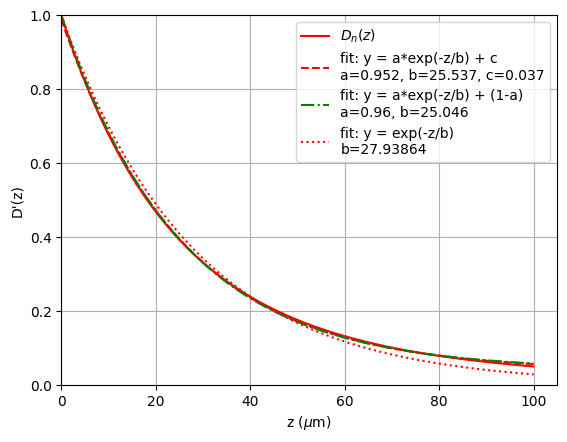

In [30]:
nps_1p7 = ResinConstituentAbsorber(
    data.absorbers['nps_in_PEGDA_2017-04-13'],
    1.7
)
resin_nps1p7 = Resin(monomers=pegda, absorbers=nps_1p7, photoinitiators=irgacure819)
# print(f"{resin_nps1p7.name=}")

irradiance_nps1p7 = Irradiance(source=source, resin=resin_nps1p7, wavelength_array_params=wavelength_array_parameters)

# Normalized dose
norm_dose_nps1p7 = NormalizedDose(irradiance=irradiance_nps1p7, z_array_params=z_array_params)
print(norm_dose_nps1p7.irradiance.resin.name)
norm_dose_nps1p7.plot();

In [31]:
np.exp(-1)

0.36787944117144233

# Normalized dose at z=20 &mu;m vs NPS concentration

Instead of choosing the NPS concentration on the basis of the fitted `b` parameter being 25 &mu;m, let's set it so that the normalized dose is 1/e at z=20 &mu;m (i.e., 1 layer thickness), which mimics the situation when we have full coverage of the source spectrum by the absorber spectrum.

In [52]:
pegda = ResinConstituentMonomer(data.monomers['PEGDA'], 100)
irgacure819 = ResinConstituentAbsorber(
    data.photoinitiators['irgacure819_in_PEGDA_2017-04-13'],
    1.0
)

nps_conc_values = np.linspace(0.5, 3.0, num=26)
normalized_dose_at_20um = []
index_for_z_equal_20um = 40

for nps_conc in nps_conc_values:
    absorber = ResinConstituentAbsorber(
        data.absorbers['nps_in_PEGDA_2017-04-13'],
        nps_conc
    )
    resin = Resin(monomers=pegda, absorbers=absorber, photoinitiators=irgacure819)
    irradiance = Irradiance(source=source, resin=resin, wavelength_array_params=wavelength_array_parameters)
    norm_dose = NormalizedDose(irradiance=irradiance, z_array_params=z_array_params)
    normalized_dose_at_20um.append(norm_dose.normalized_dose[index_for_z_equal_20um])


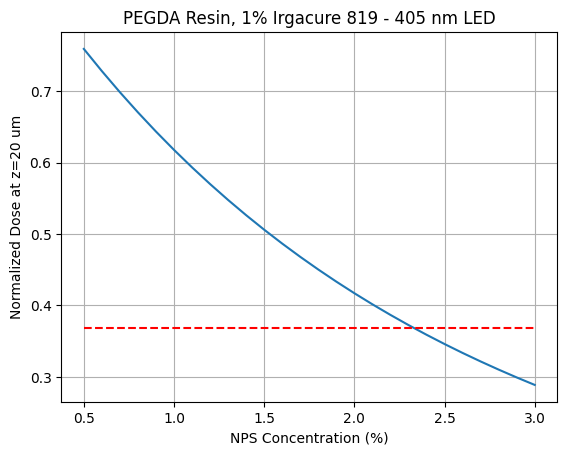

In [55]:
fig, ax = plt.subplots()
ax.plot(nps_conc_values, normalized_dose_at_20um)
ax.set_xlabel("NPS Concentration (%)")
ax.set_ylabel("Normalized Dose at z=20 um")
ax.set_title("PEGDA Resin, 1% Irgacure 819 - 405 nm LED")
ax.hlines(np.exp(-1), 0.5, 3.0, color="r", ls="--")
ax.grid()
# plt.savefig("h_a_vs_NPS_concentration.png")

In [56]:
print("NPS conc. (%) | Normalized Dose at z=20 um")
print("------------------------------------------")
for conc, h_a in zip(nps_conc_values, normalized_dose_at_20um):
    print(f"      {conc:0.2f}    |      {h_a:.3f}")

NPS conc. (%) | Normalized Dose at z=20 um
------------------------------------------
      0.50    |      0.759
      0.60    |      0.728
      0.70    |      0.699
      0.80    |      0.670
      0.90    |      0.643
      1.00    |      0.618
      1.10    |      0.593
      1.20    |      0.570
      1.30    |      0.548
      1.40    |      0.526
      1.50    |      0.506
      1.60    |      0.487
      1.70    |      0.468
      1.80    |      0.450
      1.90    |      0.433
      2.00    |      0.417
      2.10    |      0.402
      2.20    |      0.387
      2.30    |      0.373
      2.40    |      0.359
      2.50    |      0.346
      2.60    |      0.333
      2.70    |      0.322
      2.80    |      0.310
      2.90    |      0.299
      3.00    |      0.289


# NPS 2.3%

PEG-100__NPS-2.3__Irg-1


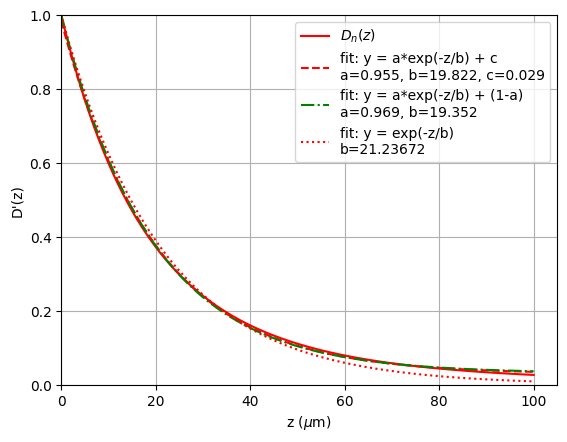

In [57]:
nps_2p3 = ResinConstituentAbsorber(
    data.absorbers['nps_in_PEGDA_2017-04-13'],
    2.3
)
resin_nps2p3 = Resin(monomers=pegda, absorbers=nps_2p3, photoinitiators=irgacure819)
# print(f"{resin_nps1p7.name=}")

irradiance_nps2p3 = Irradiance(source=source, resin=resin_nps2p3, wavelength_array_params=wavelength_array_parameters)

# Normalized dose
norm_dose_nps2p3 = NormalizedDose(irradiance=irradiance_nps2p3, z_array_params=z_array_params)
print(norm_dose_nps2p3.irradiance.resin.name)
norm_dose_nps2p3.plot();

In [63]:
print("z (um)  Normalized dose")
print(f"  {norm_dose_nps2p3.z_um[index_for_z_equal_20um]}     {norm_dose_nps2p3.normalized_dose[index_for_z_equal_20um]:.3f}")

z (um)  Normalized dose
  20.0     0.373


In [67]:
z_layer_um = 20.0
z_positions_um = z_layer_um * np.array([i for i in range(0, 11)])
z_positions_um

array([  0.,  20.,  40.,  60.,  80., 100., 120., 140., 160., 180., 200.])

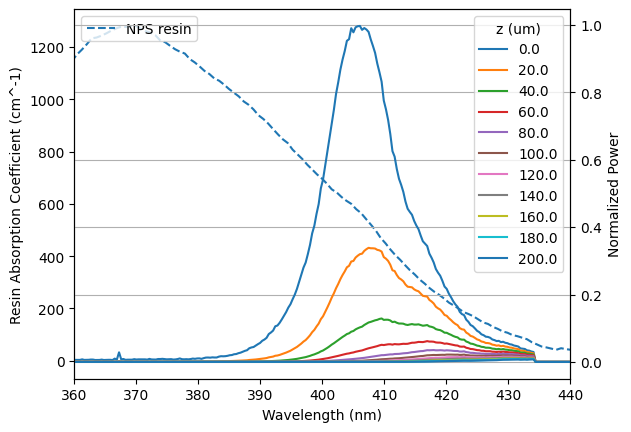

In [84]:
fig, ax = plt.subplots()
ax_right = ax.twinx()
for z in z_positions_um:
    ax_right.plot(irradiance_nps2p3.wavelengths, irradiance_nps2p3(z), label=z)
ax.set_xlim(360, 440)
ax.plot(resin_nps2p3.wavelength, resin_nps2p3.absorption_coeff_inv_cm, ls="--", label="NPS resin")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Resin Absorption Coefficient (cm^-1)")
ax_right.set_ylabel("Normalized Power")
ax_right.legend(title="z (um)")
ax.legend(loc="upper left")
ax_right.grid()